# Exploratory Data Analysis (EDA) & Data Cleaning

## Objectives

- Understand the structure of the dataset
- Explore numerical and categorical features
- Analyze the target variable
- Identify class imbalance
- Detect "unknown" values
- Remove unnecessary features
- Clean the dataset
- Save the cleaned dataset

Import Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

Load Dataset

In [2]:
df = pd.read_csv("../data/raw/bank-additional-full.csv", sep=";")

print(df.shape)

df.head()

(41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


Dataset Copy

In [3]:
df_clean = df.copy()

Shape

In [4]:
print("Rows :", df_clean.shape[0])
print("Columns :", df_clean.shape[1])

Rows : 41188
Columns : 21


Data Types

In [5]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

Missing Values

In [6]:
missing = pd.DataFrame({
    "Missing Values": df_clean.isnull().sum(),
    "Percentage": (df_clean.isnull().mean()*100).round(2)
})

missing

,Missing Values,Percentage
age,0,0.0
job,0,0.0
marital,0,0.0
education,0,0.0
default,0,0.0
housing,0,0.0
loan,0,0.0
contact,0,0.0
month,0,0.0
day_of_week,0,0.0


Observation

No actual missing values exist.

However, several categorical columns contain "unknown",
which represents unavailable information.

Duplicate Records

In [7]:
duplicates = df_clean.duplicated().sum()

print("Duplicate Records:", duplicates)

Duplicate Records: 12


Target Distribution

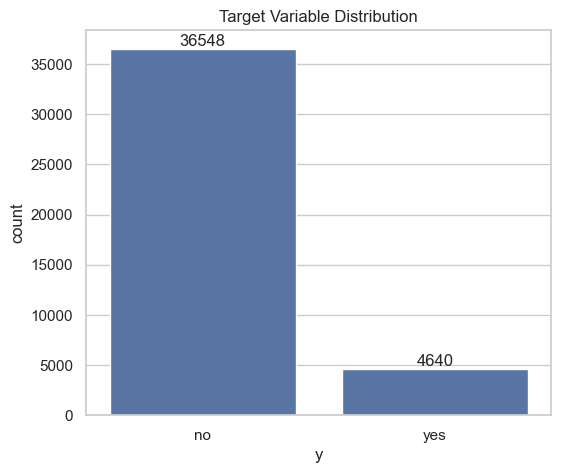

In [8]:
plt.figure(figsize=(6,5))

ax = sns.countplot(data=df_clean, x="y")

plt.title("Target Variable Distribution")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

Target Percentage

In [9]:
target_percentage = (
    df_clean["y"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

target_percentage

y
no     88.73
yes    11.27
Name: proportion, dtype: float64

Numerical Features

In [10]:
numerical_features = df_clean.select_dtypes(include=["int64", "float64"]).columns.tolist()

print(f"Total Numerical Features: {len(numerical_features)}")
numerical_features

Total Numerical Features: 10


['age',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'emp.var.rate',
 'cons.price.idx',
 'cons.conf.idx',
 'euribor3m',
 'nr.employed']

Categorical Features

In [11]:
categorical_features = df_clean.select_dtypes(include=["object"]).columns.tolist()

print(f"Total Categorical Features: {len(categorical_features)}")
categorical_features

Total Categorical Features: 11


['job',
 'marital',
 'education',
 'default',
 'housing',
 'loan',
 'contact',
 'month',
 'day_of_week',
 'poutcome',
 'y']

Numerical Statistics

In [12]:
df_clean[numerical_features].describe().T

,count,mean,std,min,25%,50%,75%,max
age,41188.0,40.024060,10.421250,17.000,32.000,38.000,47.000,98.000
duration,41188.0,258.285010,259.279249,0.000,102.000,180.000,319.000,4918.000
campaign,41188.0,2.567593,2.770014,1.000,1.000,2.000,3.000,56.000
pdays,41188.0,962.475454,186.910907,0.000,999.000,999.000,999.000,999.000
previous,41188.0,0.172963,0.494901,0.000,0.000,0.000,0.000,7.000
emp.var.rate,41188.0,0.081886,1.570960,-3.400,-1.800,1.100,1.400,1.400
cons.price.idx,41188.0,93.575664,0.578840,92.201,93.075,93.749,93.994,94.767
cons.conf.idx,41188.0,-40.502600,4.628198,-50.800,-42.700,-41.800,-36.400,-26.900
euribor3m,41188.0,3.621291,1.734447,0.634,1.344,4.857,4.961,5.045
nr.employed,41188.0,5167.035911,72.251528,4963.600,5099.100,5191.000,5228.100,5228.100


Distribution of Numerical Features

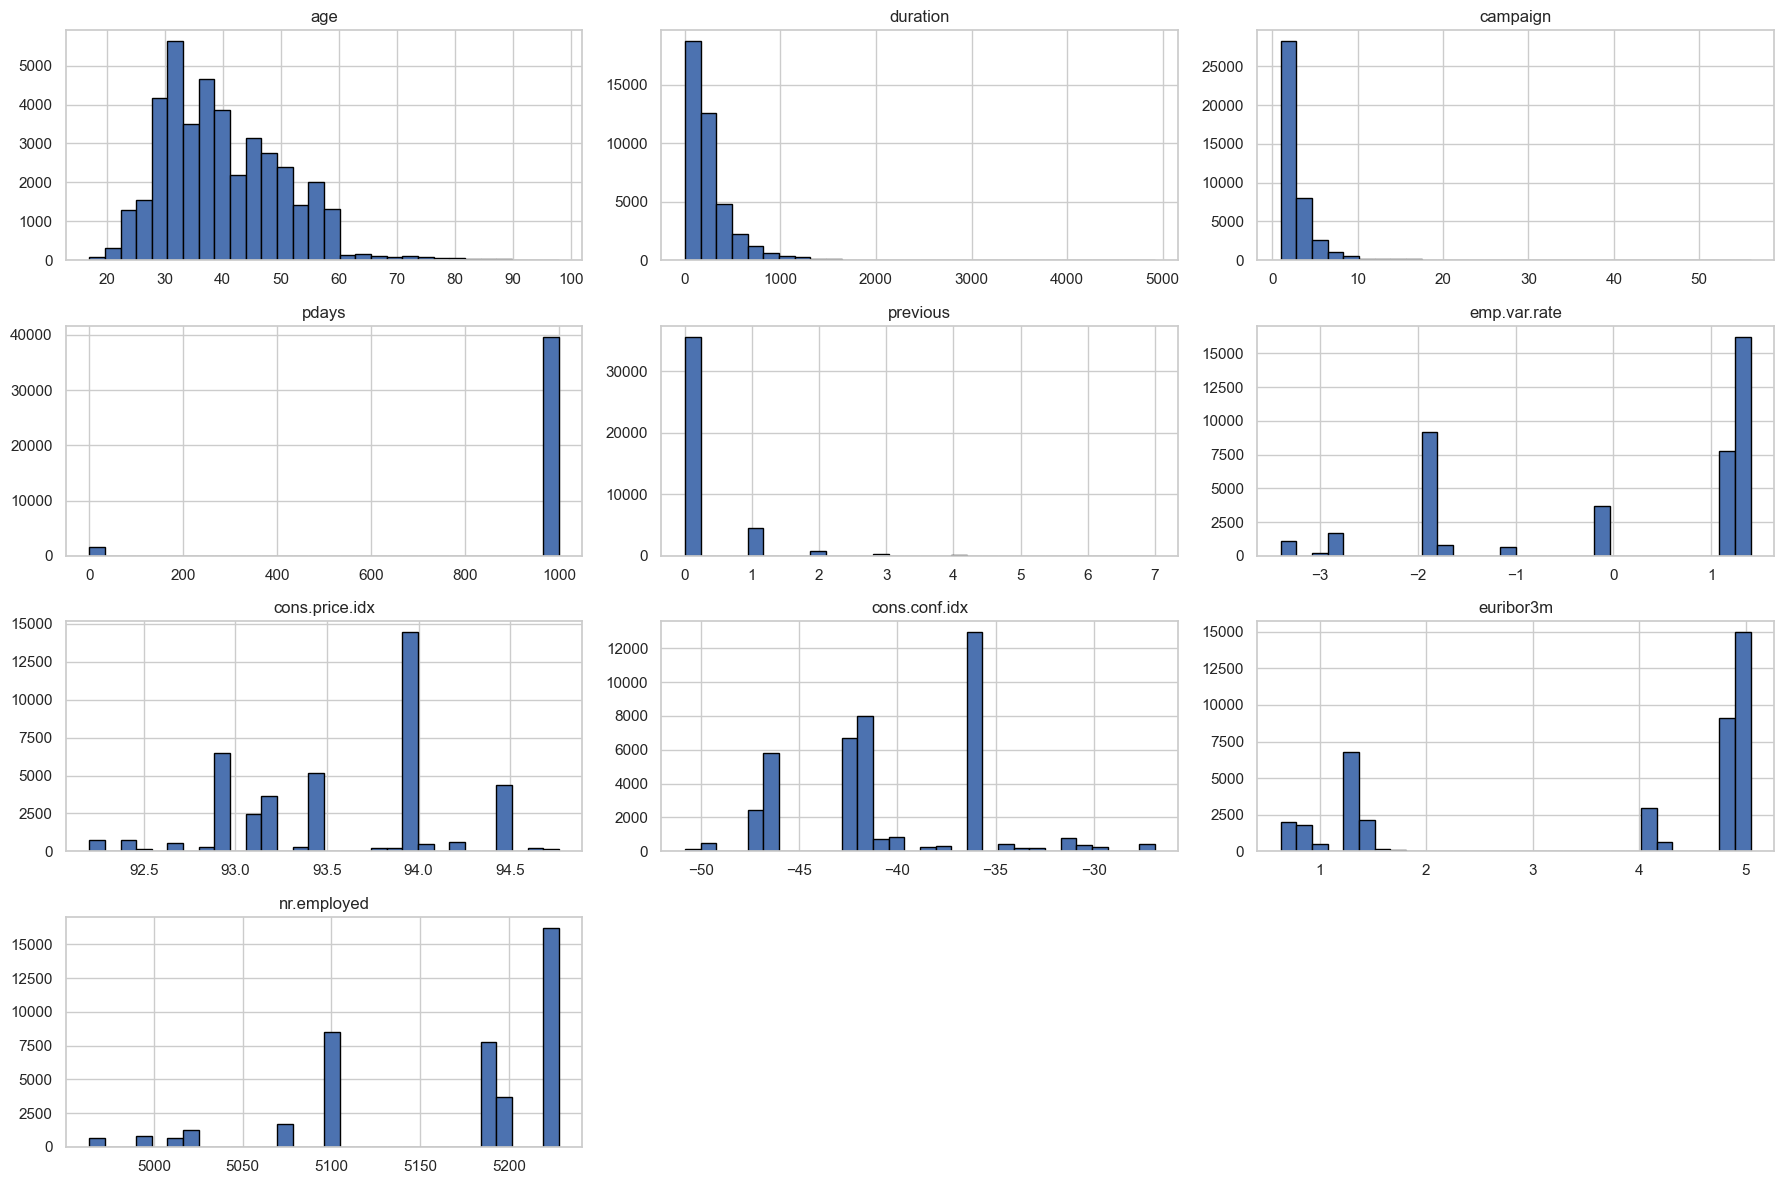

In [13]:
df_clean[numerical_features].hist(
    figsize=(18,12),
    bins=30,
    edgecolor="black"
)

plt.tight_layout()

plt.show()

Observation

Most numerical variables are skewed.

Features like duration, campaign and previous
contain outliers.

Scaling may be required for distance-based algorithms.

Boxplots (Outlier Detection)

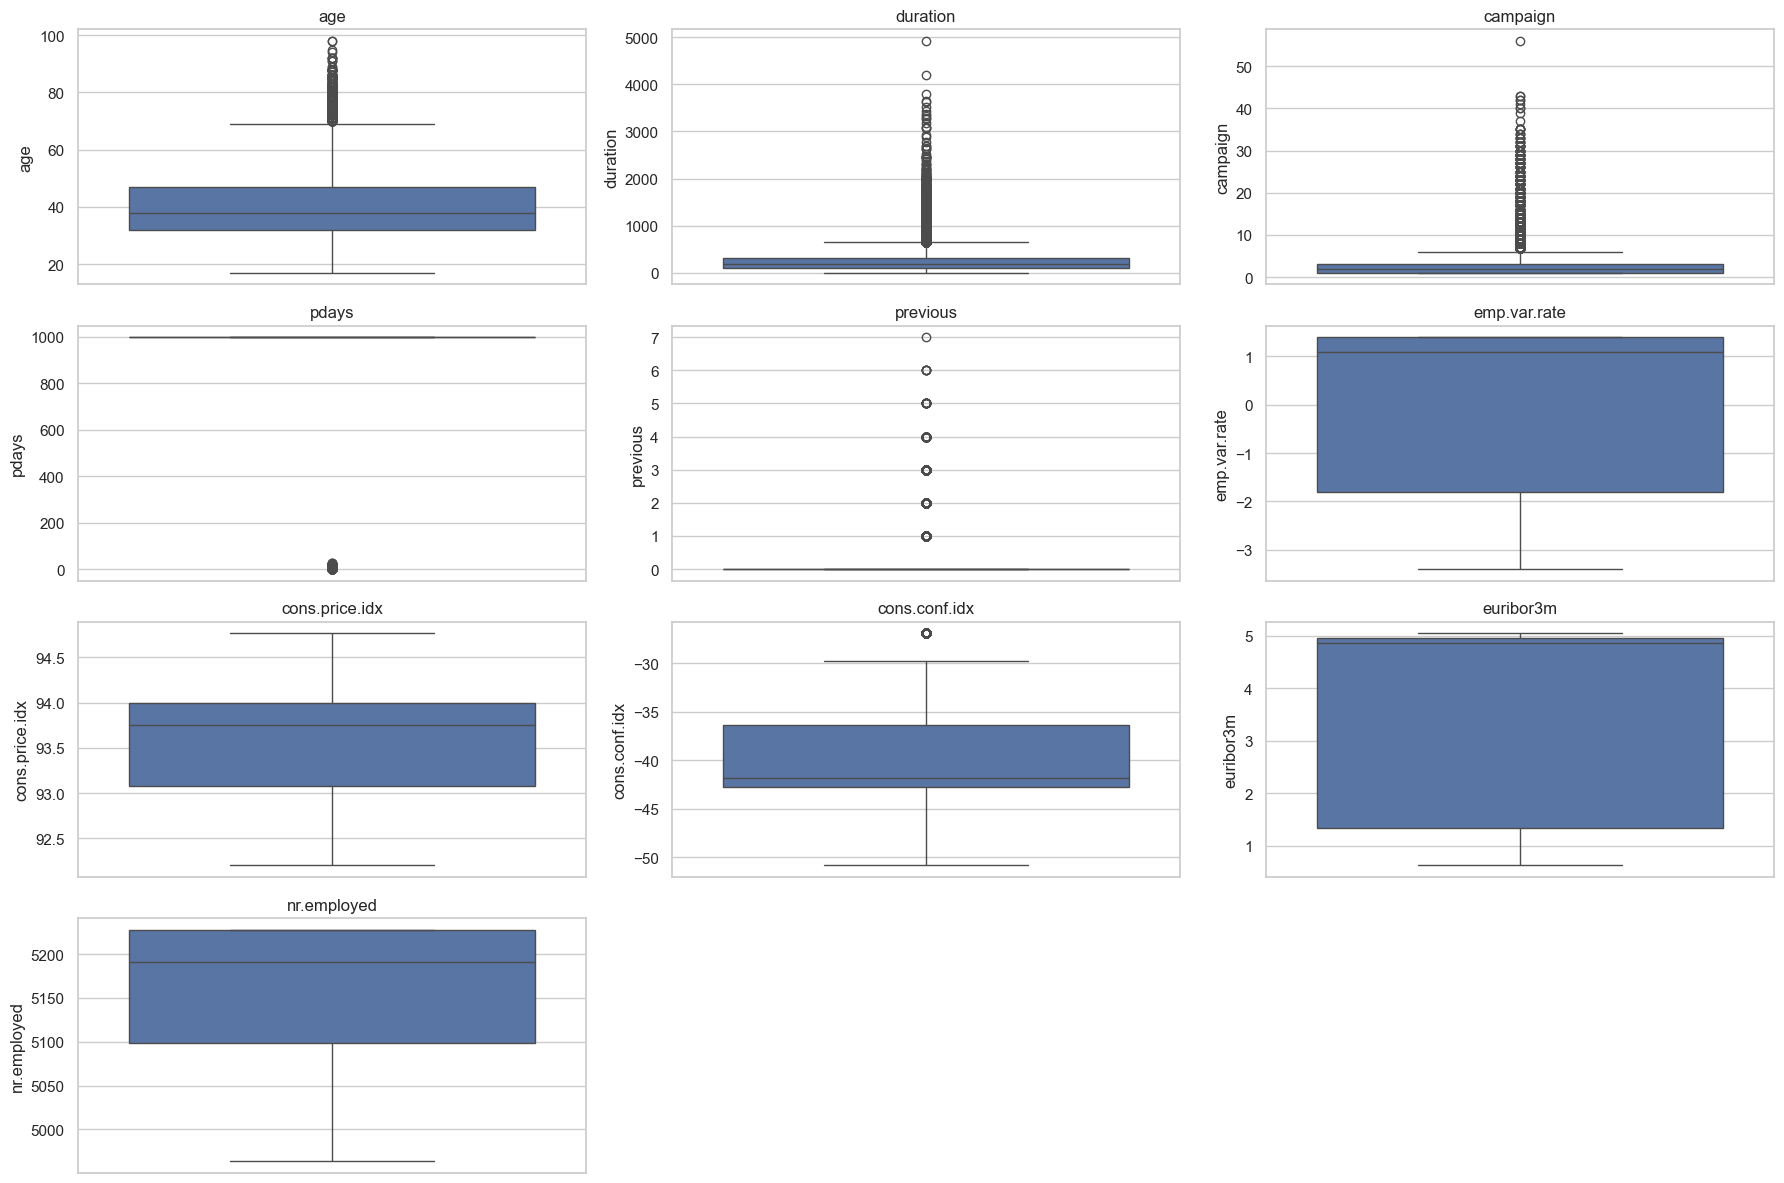

In [14]:
plt.figure(figsize=(18,12))

for i, col in enumerate(numerical_features, 1):

    plt.subplot(4,3,i)

    sns.boxplot(y=df_clean[col])

    plt.title(col)

plt.tight_layout()

plt.show()

Business Insight

Outliers exist in several campaign-related variables.

Since these represent real customer behavior,
they will not be removed immediately.

Correlation Matrix

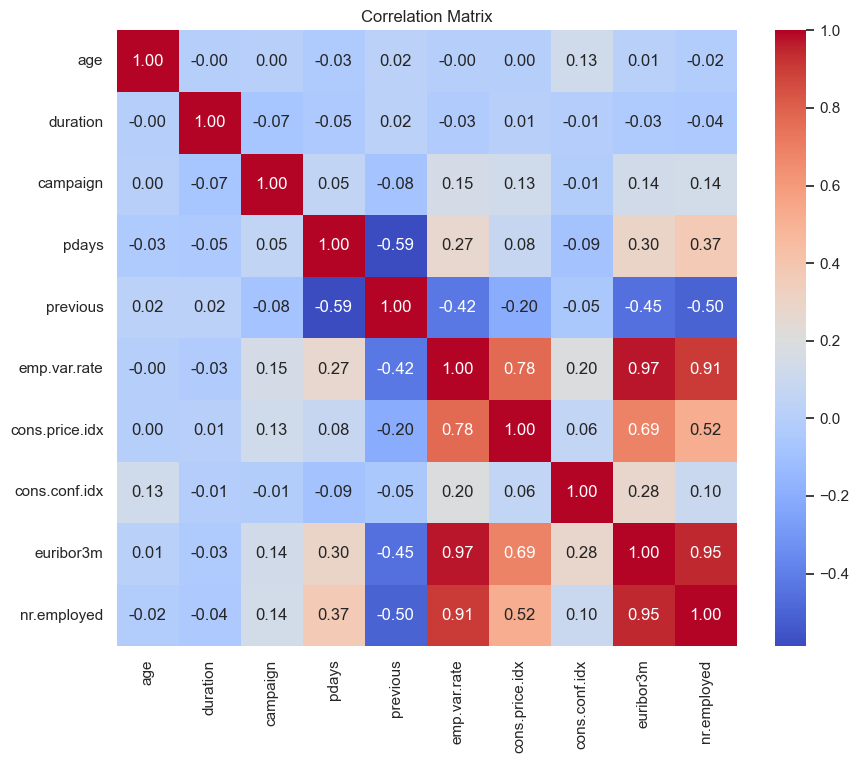

In [15]:
plt.figure(figsize=(10,8))

corr = df_clean[numerical_features].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

Observation

No severe multicollinearity exists.

Most numerical variables have weak to moderate correlations.

Target vs Numerical Features

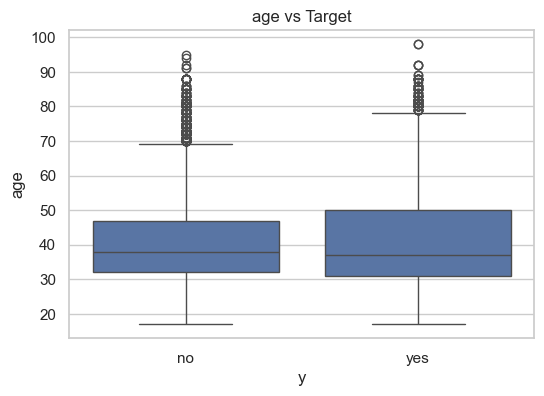

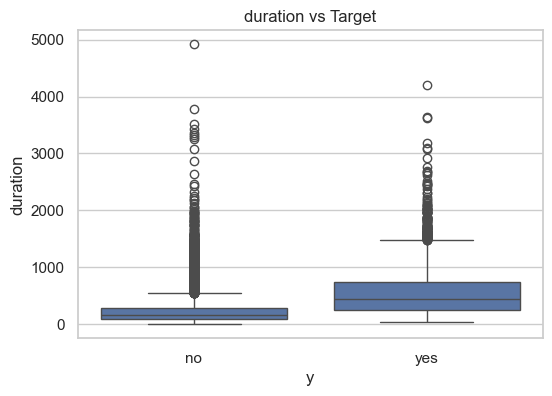

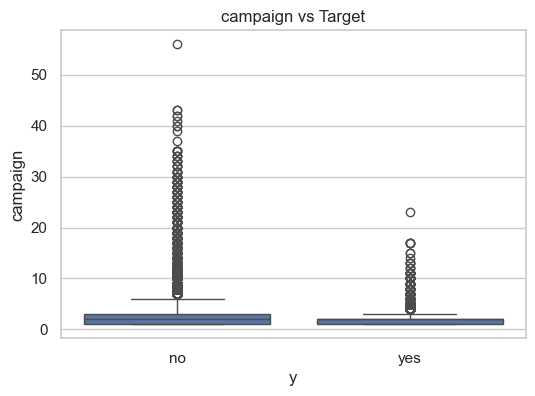

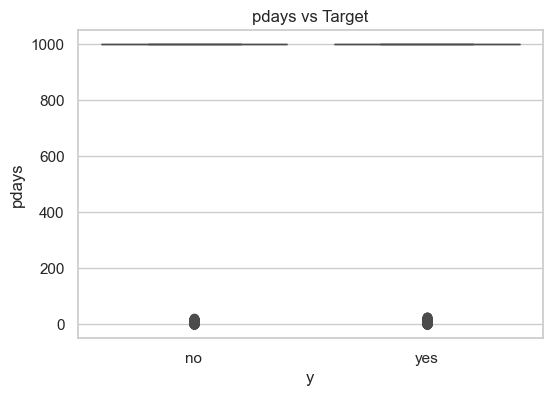

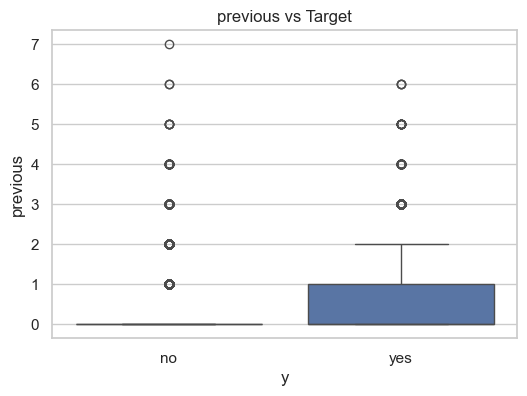

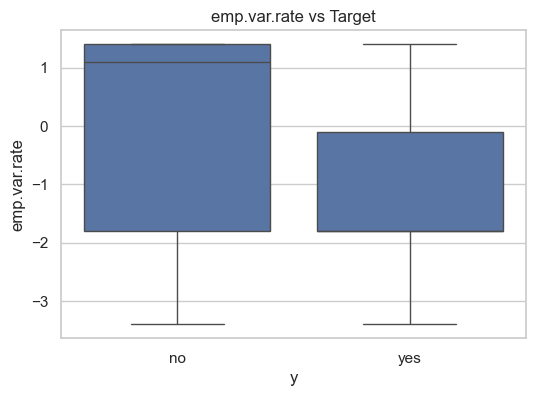

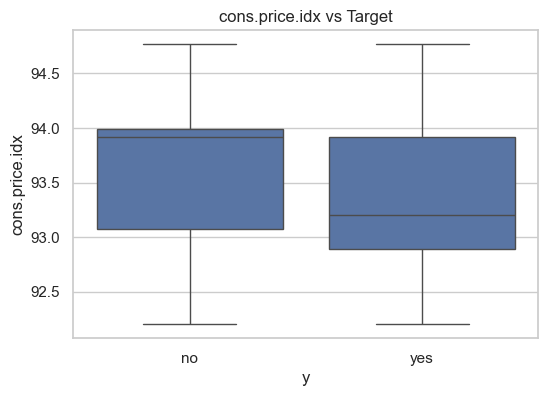

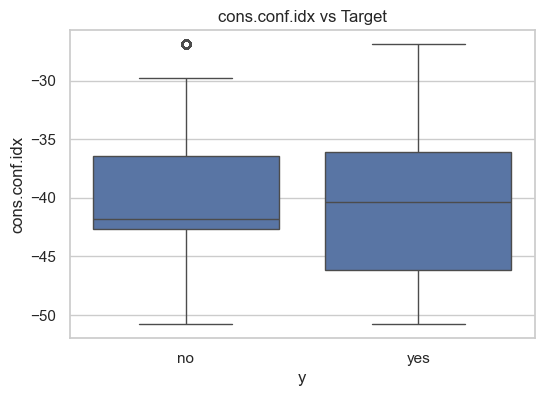

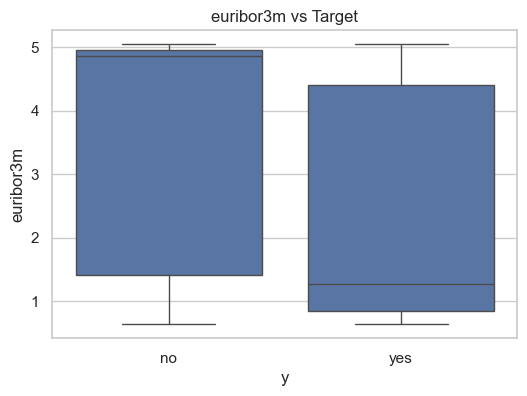

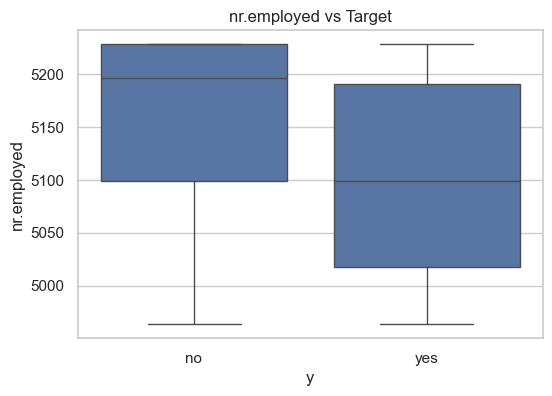

In [16]:
for col in numerical_features:

    plt.figure(figsize=(6,4))

    sns.boxplot(
        data=df_clean,
        x="y",
        y=col
    )

    plt.title(f"{col} vs Target")

    plt.show()

Distribution by Target

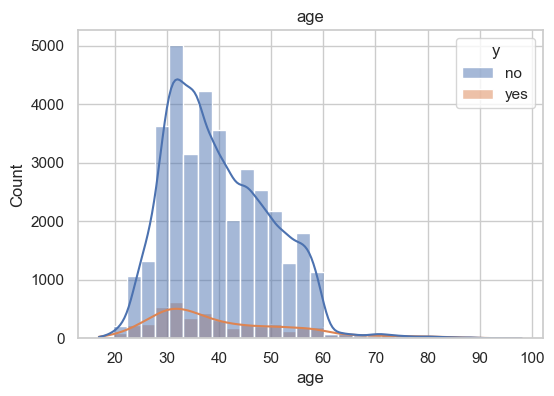

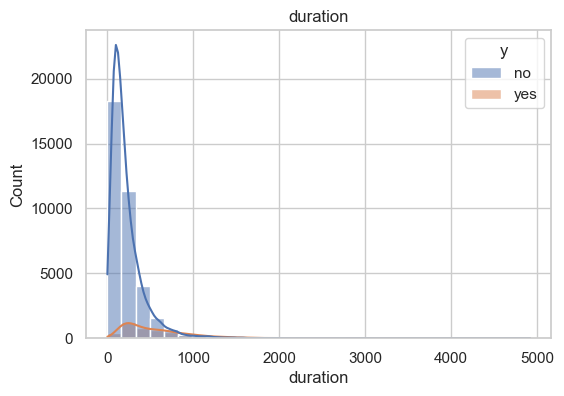

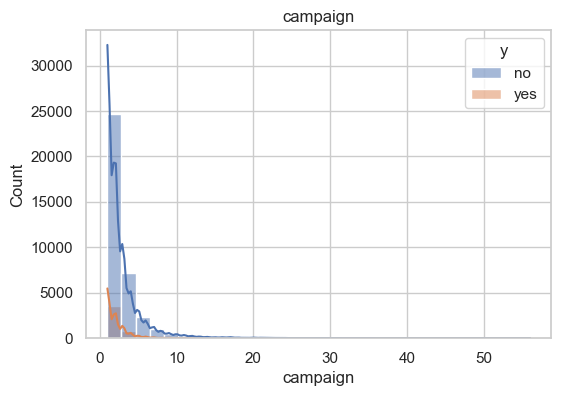

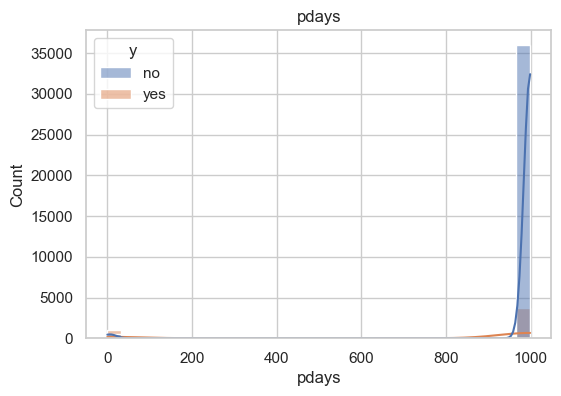

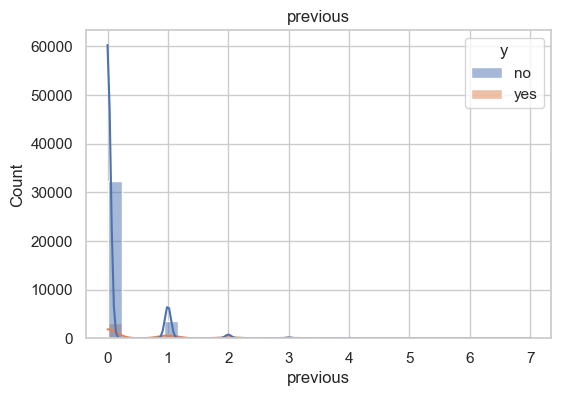

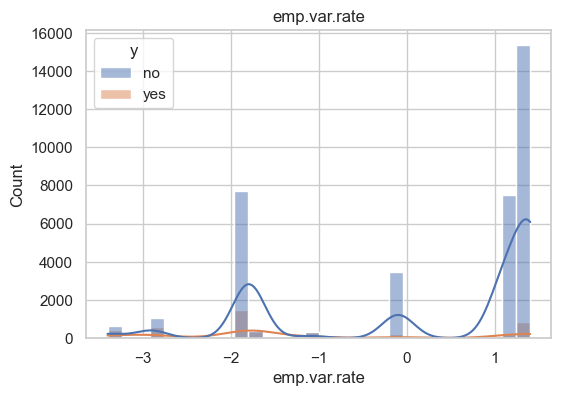

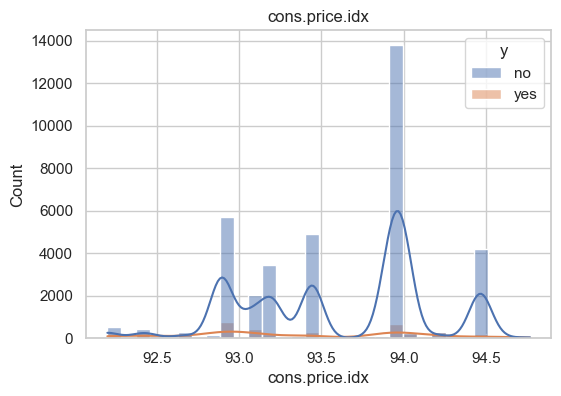

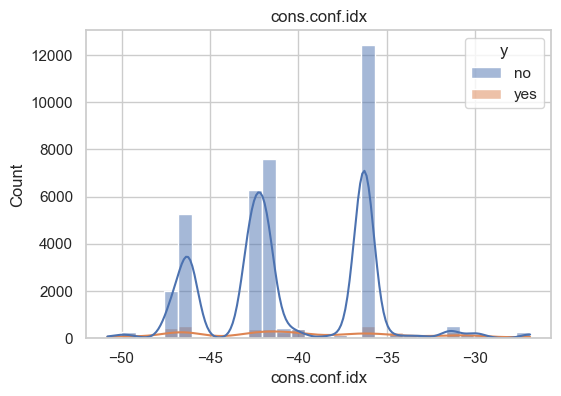

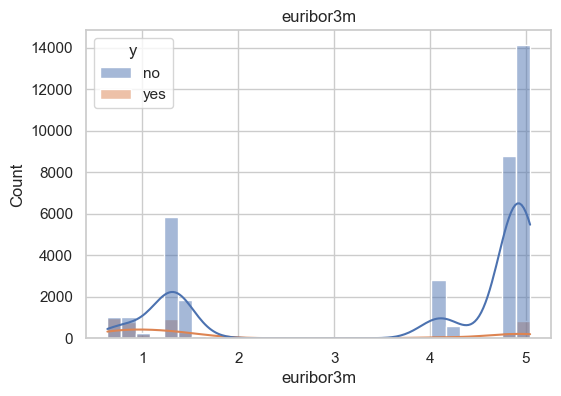

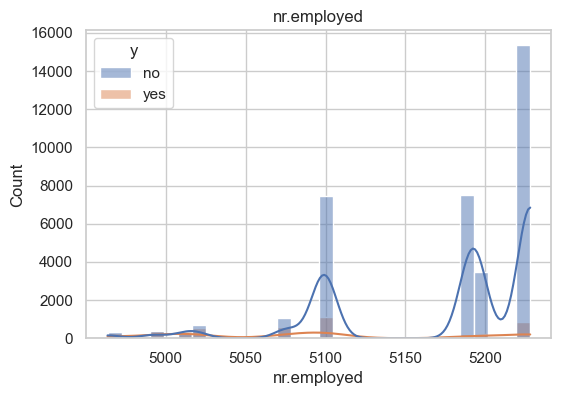

In [17]:
for col in numerical_features:

    plt.figure(figsize=(6,4))

    sns.histplot(
        data=df_clean,
        x=col,
        hue="y",
        kde=True,
        bins=30
    )

    plt.title(col)

    plt.show()

Summary

In [18]:
summary = df_clean[numerical_features].agg(
    ["mean","median","std","min","max"]
).T

summary

,mean,median,std,min,max
age,40.024060,38.000,10.421250,17.000,98.000
duration,258.285010,180.000,259.279249,0.000,4918.000
campaign,2.567593,2.000,2.770014,1.000,56.000
pdays,962.475454,999.000,186.910907,0.000,999.000
previous,0.172963,0.000,0.494901,0.000,7.000
emp.var.rate,0.081886,1.100,1.570960,-3.400,1.400
cons.price.idx,93.575664,93.749,0.578840,92.201,94.767
cons.conf.idx,-40.502600,-41.800,4.628198,-50.800,-26.900
euribor3m,3.621291,4.857,1.734447,0.634,5.045
nr.employed,5167.035911,5191.000,72.251528,4963.600,5228.100


Save Summary

In [19]:
summary.to_csv("../reports/numerical_summary.csv")

print("Numerical summary saved successfully.")

Numerical summary saved successfully.


Analyze Categorical Features

In [20]:
categorical_features = df_clean.select_dtypes(include="object").columns.tolist()

# Target variable ko remove kar dete hain
categorical_features.remove("y")

print(f"Total Categorical Features: {len(categorical_features)}")
categorical_features

Total Categorical Features: 10


['job',
 'marital',
 'education',
 'default',
 'housing',
 'loan',
 'contact',
 'month',
 'day_of_week',
 'poutcome']

Value Counts for All Categorical Features

In [21]:
for col in categorical_features:
    print(f"{col.upper()}")
    print(df_clean[col].value_counts())
    print()

JOB
job
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64

MARITAL
marital
married     24928
single      11568
divorced     4612
unknown        80
Name: count, dtype: int64

EDUCATION
education
university.degree      12168
high.school             9515
basic.9y                6045
professional.course     5243
basic.4y                4176
basic.6y                2292
unknown                 1731
illiterate                18
Name: count, dtype: int64

DEFAULT
default
no         32588
unknown     8597
yes            3
Name: count, dtype: int64

HOUSING
housing
yes        21576
no         18622
unknown      990
Name: count, dtype: int64

LOAN
loan
no         33950
yes         6248
unknown      990
Name: count, dtype: int64

CONTACT
contact
cel

Count Plots of All Categorical Features

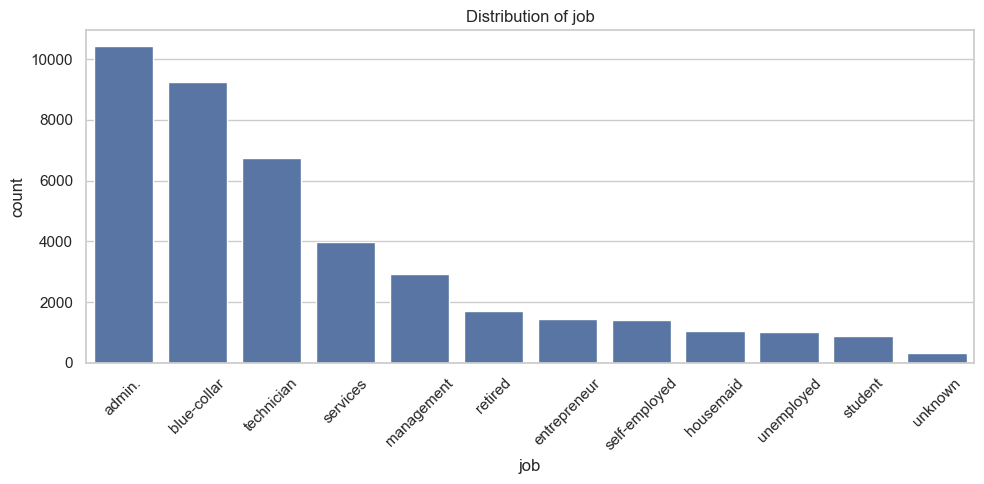

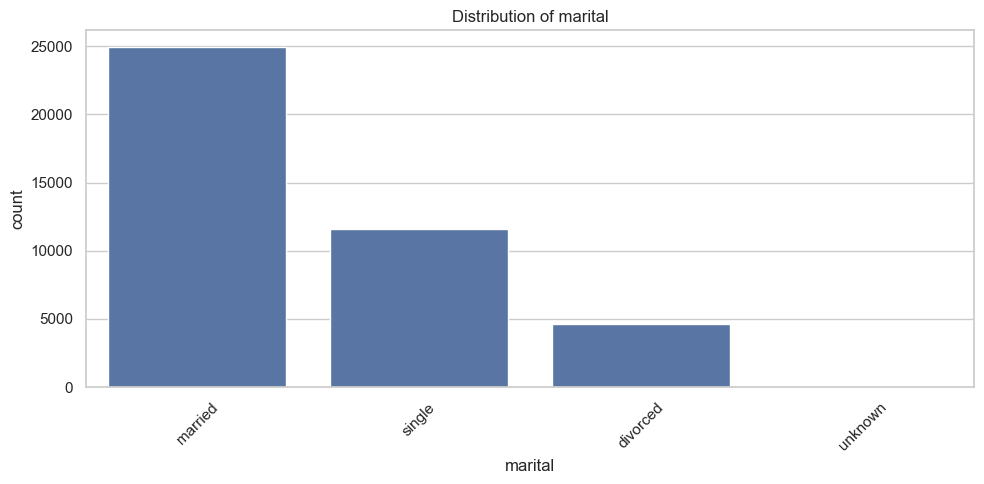

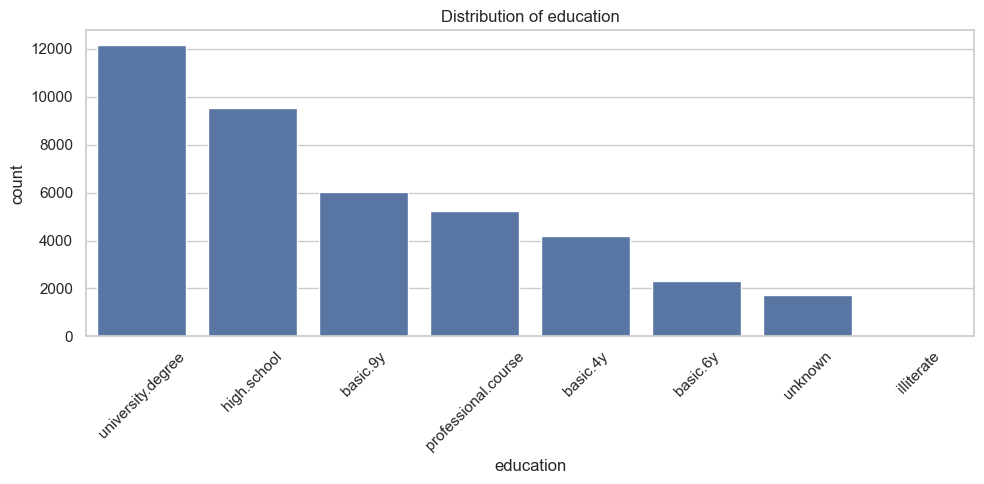

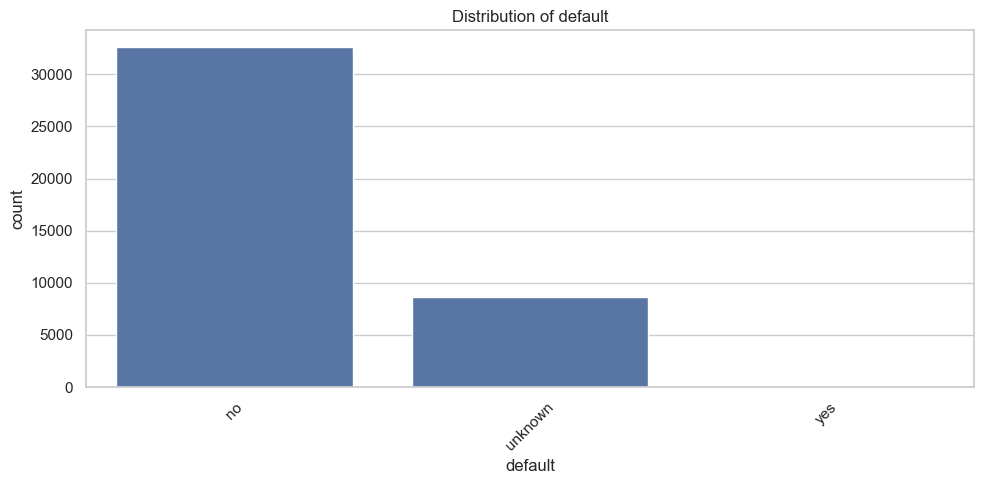

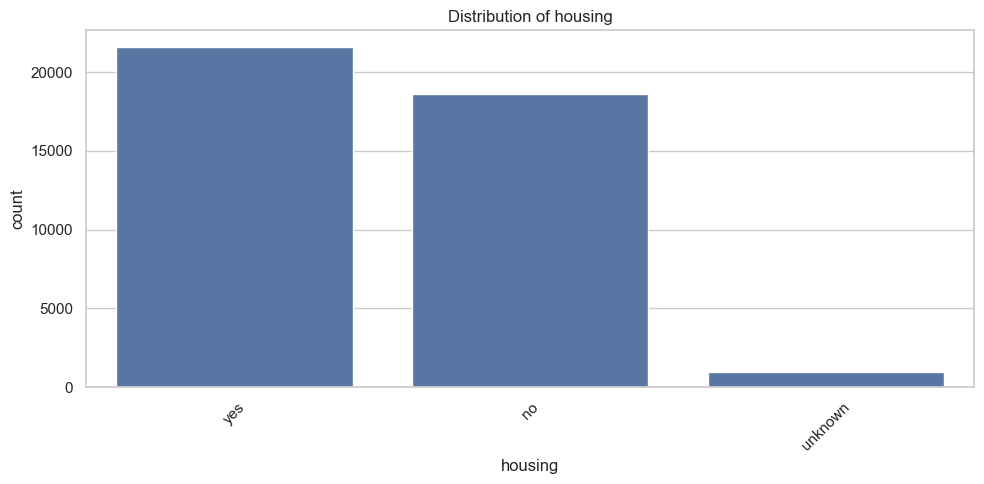

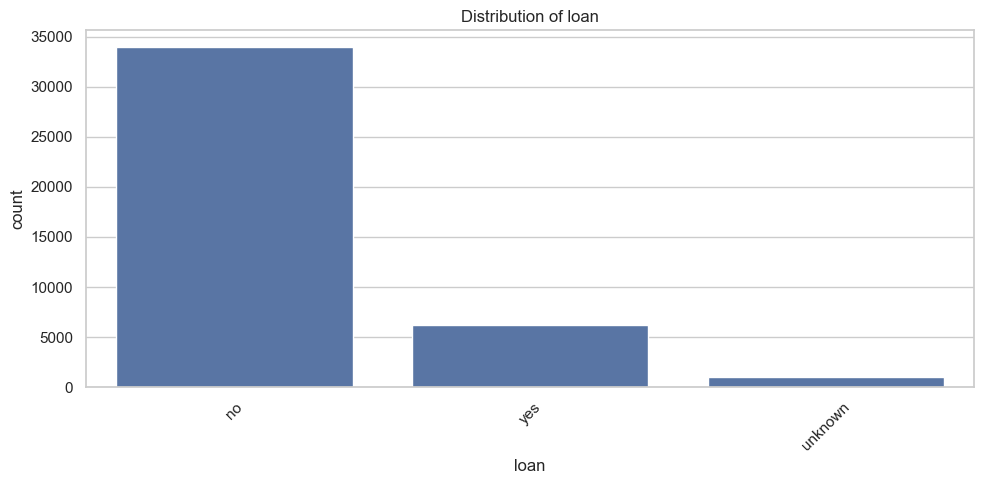

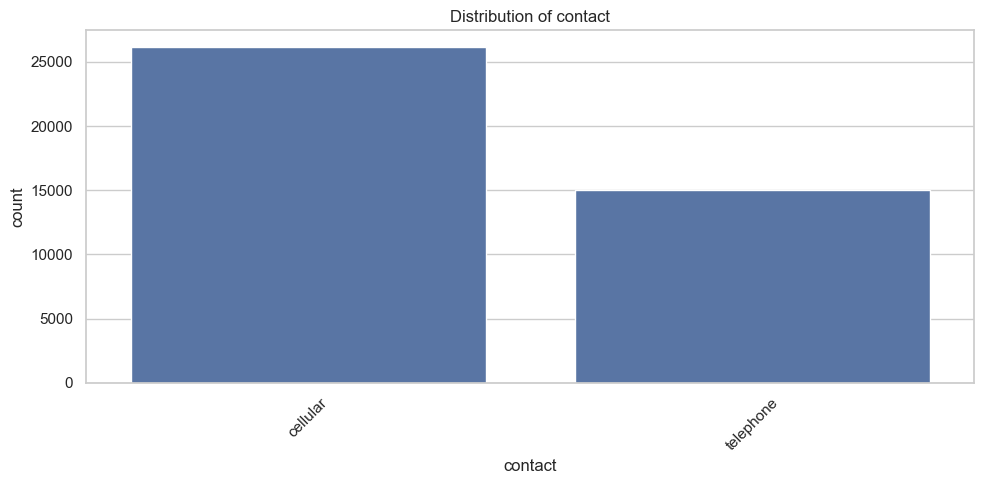

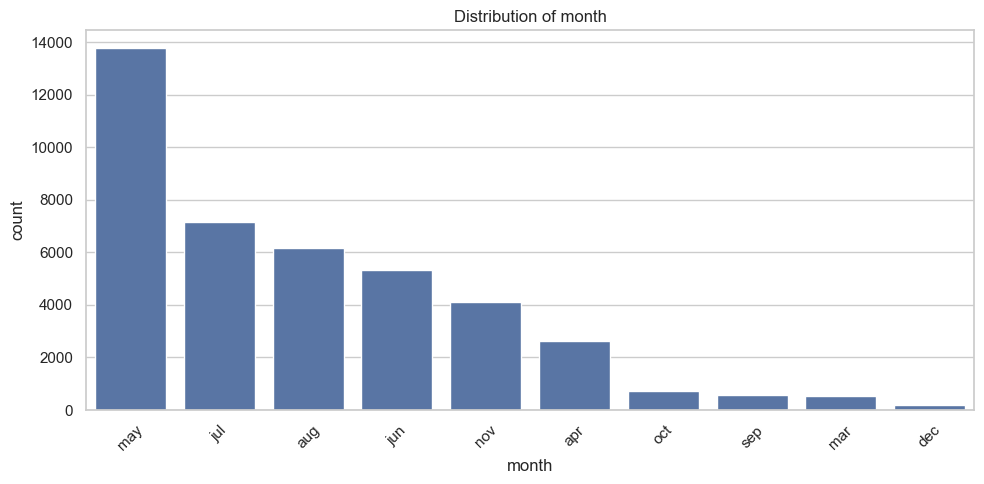

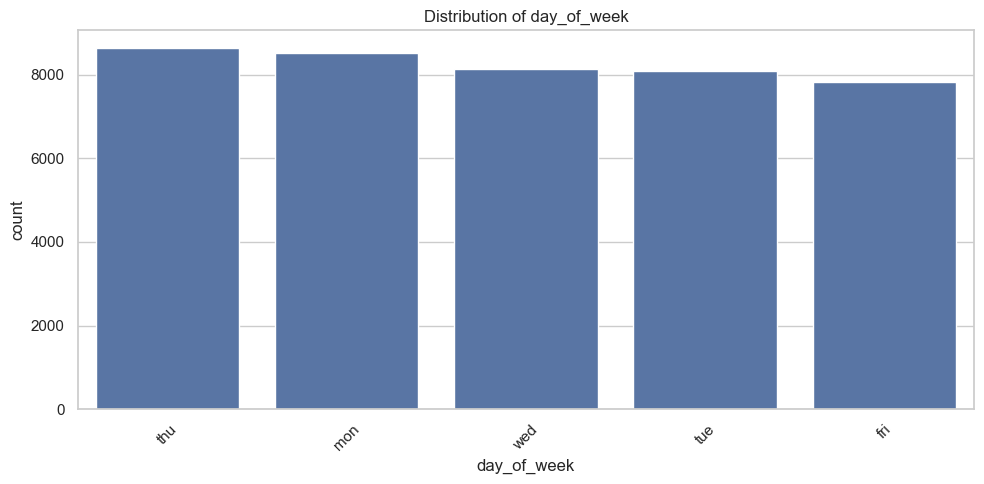

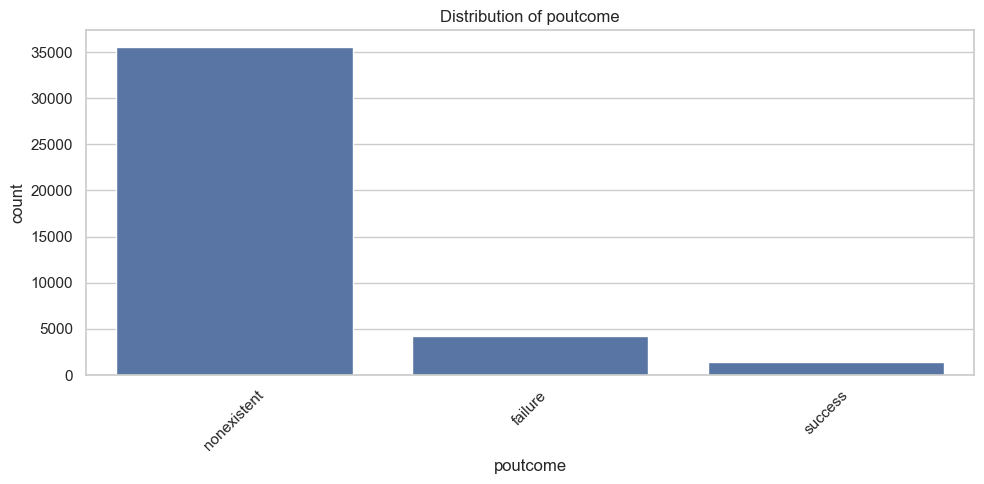

In [22]:
for col in categorical_features:

    plt.figure(figsize=(10,5))

    sns.countplot(
        data=df_clean,
        x=col,
        order=df_clean[col].value_counts().index
    )

    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

Categorical Features vs Target

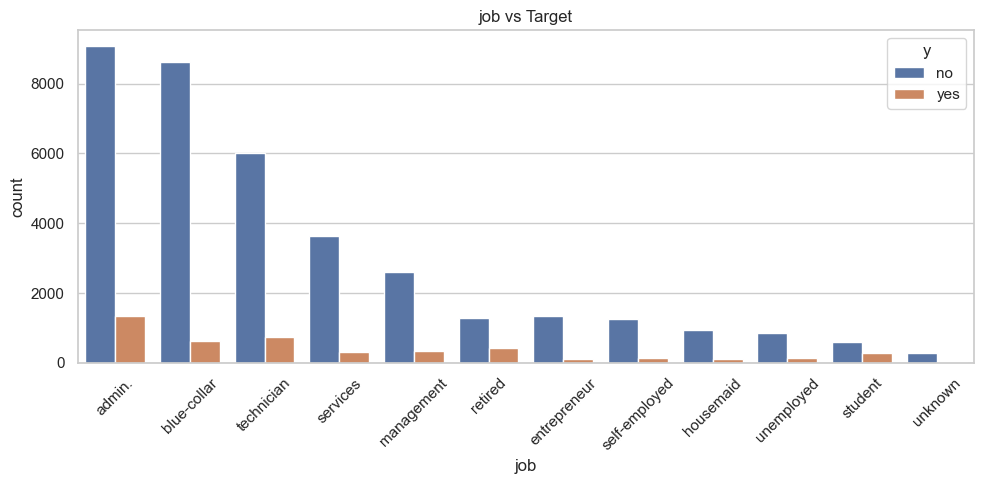

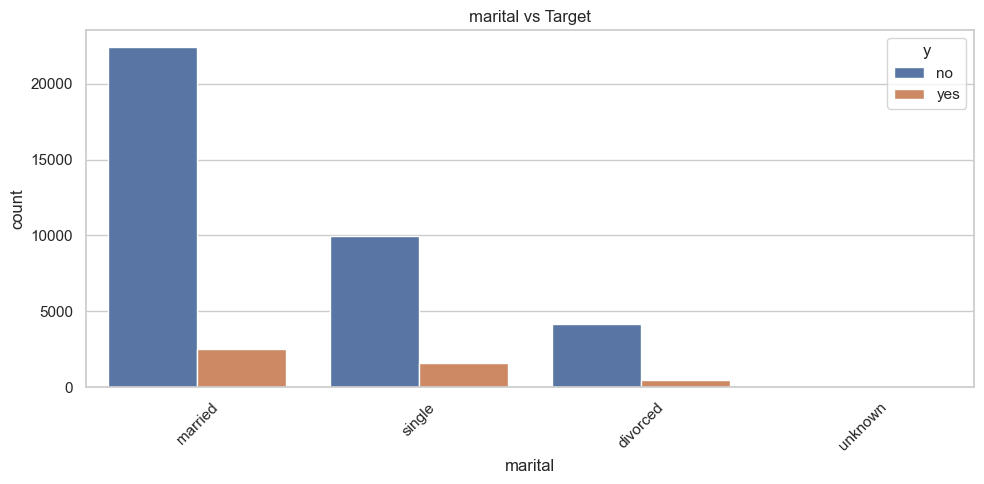

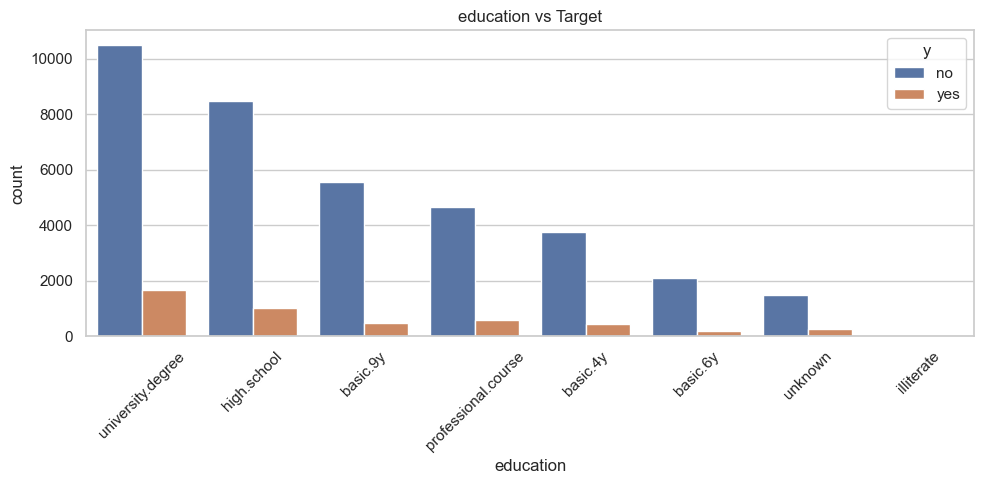

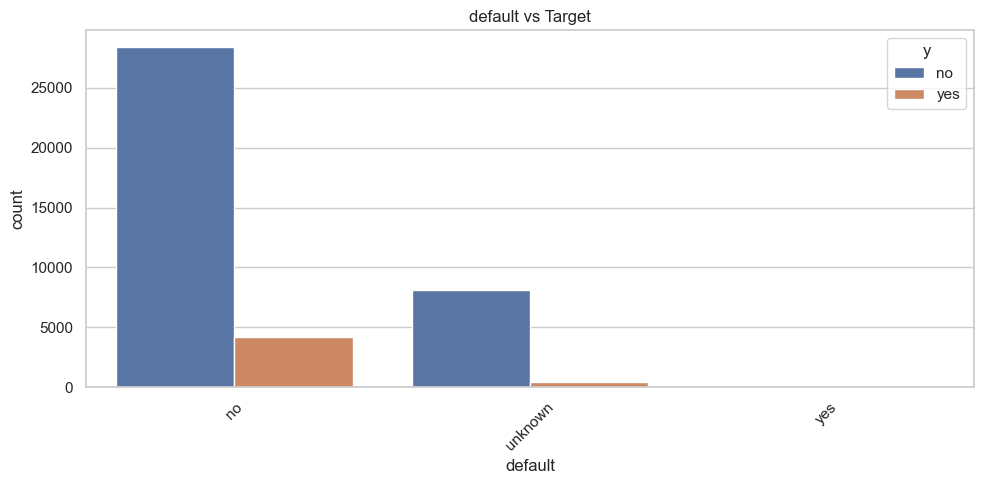

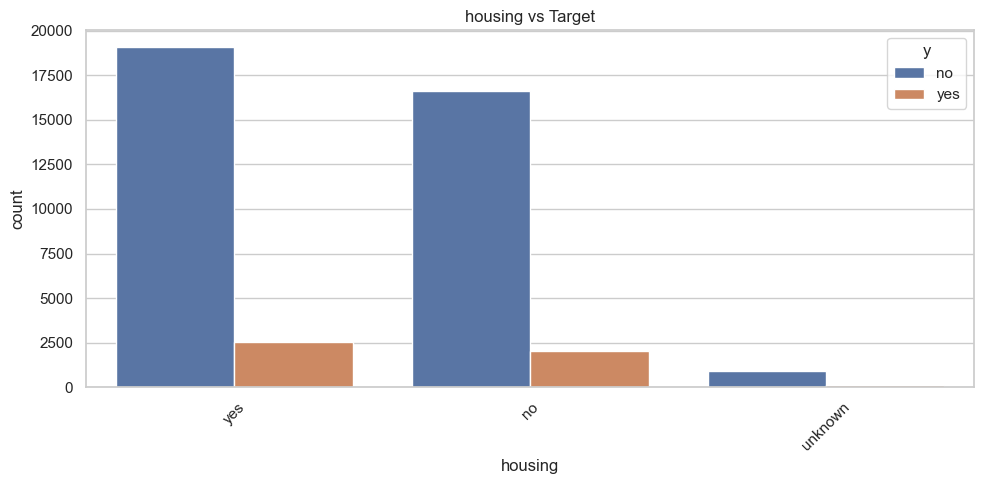

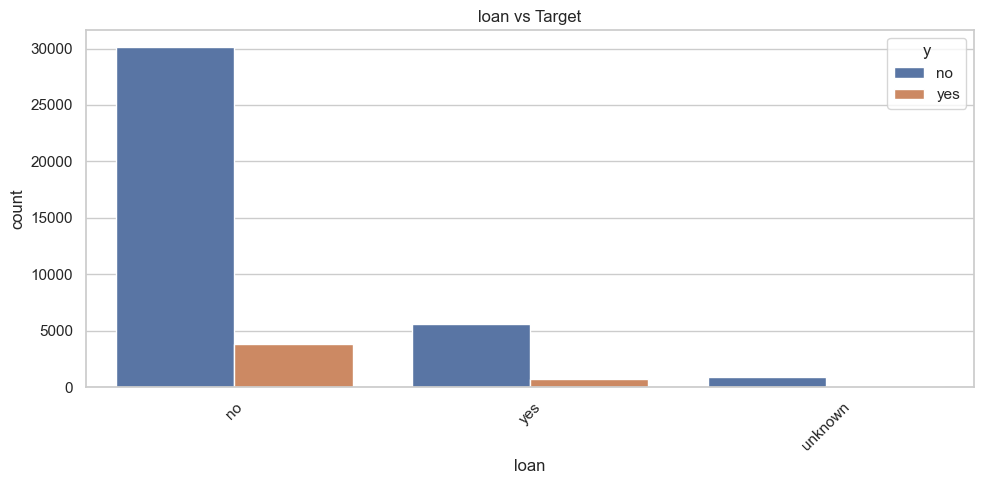

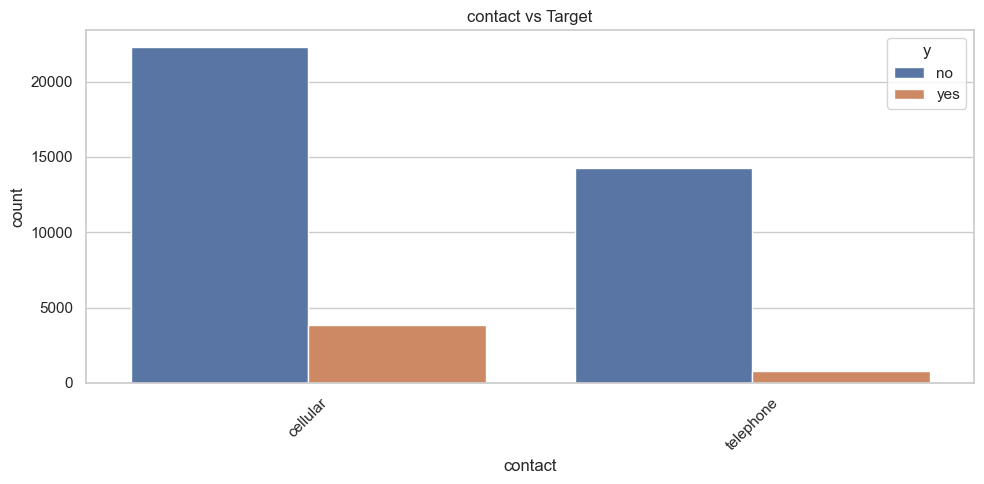

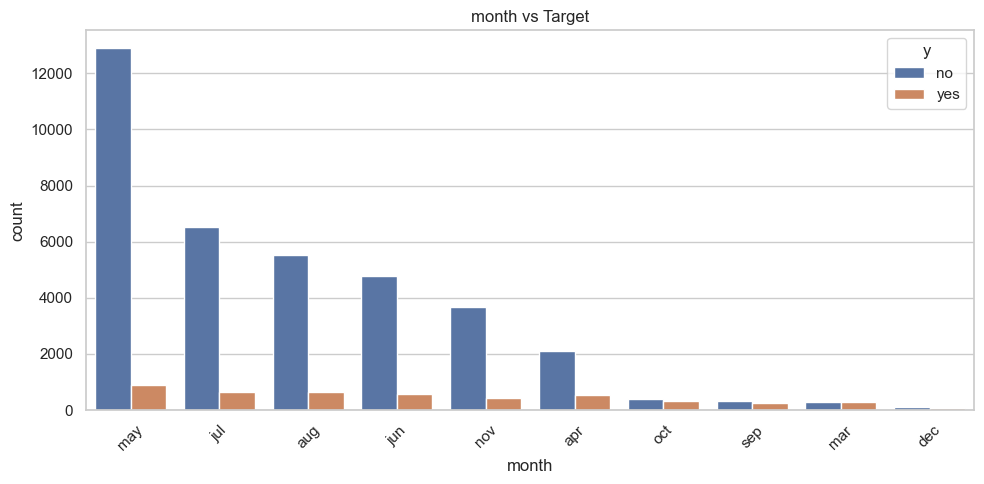

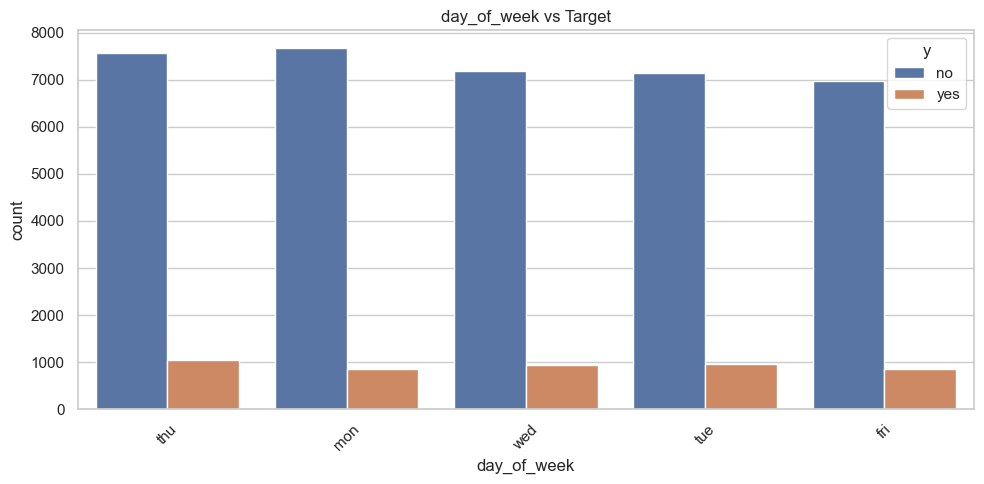

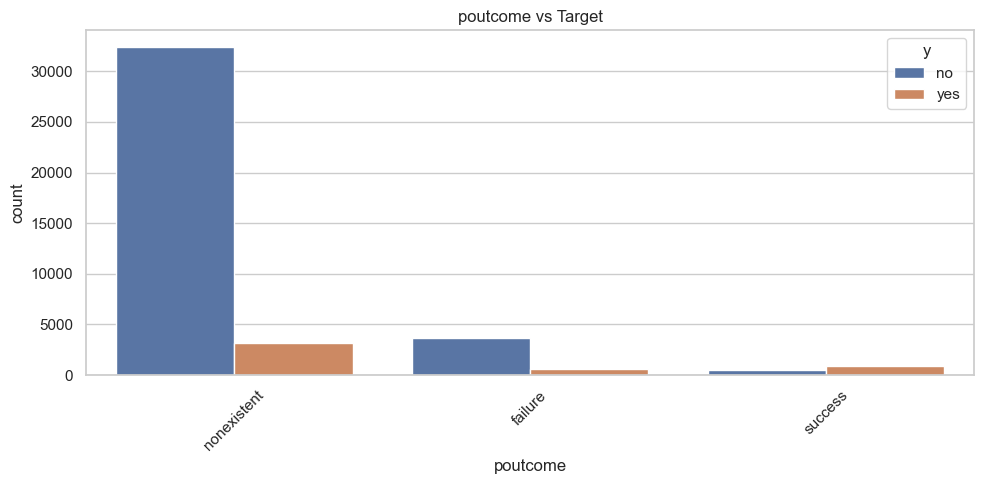

In [23]:
for col in categorical_features:

    plt.figure(figsize=(10,5))

    sns.countplot(
        data=df_clean,
        x=col,
        hue="y",
        order=df_clean[col].value_counts().index
    )

    plt.title(f"{col} vs Target")

    plt.xticks(rotation=45)

    plt.tight_layout()

    plt.show()

Unknown Values Analysis

In [24]:
unknown_counts = (
    df_clean[categorical_features]
    .apply(lambda x: (x == "unknown").sum())
    .sort_values(ascending=False)
)

unknown_df = pd.DataFrame({
    "Unknown Count": unknown_counts,
    "Percentage": (unknown_counts / len(df_clean) * 100).round(2)
})

unknown_df

,Unknown Count,Percentage
default,8597,20.87
education,1731,4.20
housing,990,2.40
loan,990,2.40
job,330,0.80
marital,80,0.19
contact,0,0.00
month,0,0.00
day_of_week,0,0.00
poutcome,0,0.00


## Observation

The dataset contains "unknown" categories instead of missing values.

These values represent unavailable customer information.

We will treat them during data preprocessing instead of dropping rows.

Remove Duration Feature

In [25]:
df_clean.drop(columns="duration", inplace=True)

print("Duration feature removed.")
print(df_clean.shape)

Duration feature removed.
(41188, 20)


Verify Dataset

In [26]:
df_clean.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


Save Clean Dataset

In [27]:
df_clean.to_csv(
    "../data/processed/df_clean.csv",
    index=False
)

print("Clean dataset saved successfully.")

Clean dataset saved successfully.


Cleaning Summary

In [28]:
print("DATA CLEANING SUMMARY")

print(f"Original Shape : {df.shape}")
print(f"Clean Shape    : {df_clean.shape}")

print("\nChanges Made:")
print("✔ Duration feature removed")
print("✔ Unknown values identified")
print("✔ Dataset saved as df_clean.csv")

DATA CLEANING SUMMARY
Original Shape : (41188, 21)
Clean Shape    : (41188, 20)

Changes Made:
✔ Duration feature removed
✔ Unknown values identified
✔ Dataset saved as df_clean.csv


# Notebook 02 Conclusion

The exploratory data analysis revealed:

- The target variable is highly imbalanced.
- Several numerical features contain outliers.
- Most numerical features are right-skewed.
- No actual missing values exist.
- Some categorical variables contain "unknown" values.
- The "duration" feature was removed to prevent data leakage.
- The cleaned dataset has been saved for feature engineering.

The next notebook will focus on:

- Feature Engineering
- Customer Segmentation
- K-Means Clustering
- Preprocessing Pipeline